# EDA completo - Port Lead Time Prediction

Este notebook faz uma analise exploratoria completa da base analitica do projeto, com foco em lead time portuario e nos fatores que podem explicar variacoes de espera, operacao e estadia total.

Base principal: `data/processed/eda_base.parquet`.

Escopo do EDA:
- inventario dos dados e linhagem das bases;
- qualidade, cobertura e consistencia temporal;
- distribuicao dos targets de lead time;
- analise por porto, regiao, rota, tipo de operacao e embarcacao;
- sazonalidade e tendencia temporal;
- congestionamento historico;
- clima e associacoes com os targets;
- outliers, caudas longas e riscos para modelagem;
- tabelas e figuras exportaveis para relatorio.


## 1. Setup

As dependencias declaradas no projeto sao `pandas`, `pyarrow`, `jupyter` e `ipykernel`. Para visualizacoes mais ricas, o notebook usa tambem `numpy`, `matplotlib` e tenta usar `seaborn` quando disponivel.


In [18]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None
    plt.style.use("ggplot")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

EDA_BASE_FILE = PROCESSED_DIR / "eda_base.parquet"
QC_FILE = INTERIM_DIR / "master_port_calls_qc.parquet"
TARGET_BASE_FILE = INTERIM_DIR / "target_base.parquet"

print(PROJECT_ROOT)


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction


## 2. Funcoes auxiliares

As funcoes abaixo mantem o notebook enxuto e padronizam metricas, missing values, resumo de grupos e graficos de distribuicao.


In [19]:
TARGETS_H = [
    "t_wait_for_berthing_h",
    "t_operation_h",
    "t_post_operation_h",
    "t_total_port_stay_h",
]

TARGETS_D = [col.replace("_h", "_d") for col in TARGETS_H]

ID_COLS = [
    "port_call_id", "port", "port_name", "port_display", "imo", "vessel_id",
    "vessel_name", "operation_type", "source_port", "source_port_name",
    "destination_port", "destination_port_name",
]

TIME_COLS = ["arrival_port_ts", "berthing_ts", "unberthing_ts", "departure_port_ts", "arrival_date", "date"]

WEATHER_COLS = [
    "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min",
    "precipitation_sum", "rain_sum", "precipitation_hours",
    "wind_speed_10m_max", "wind_gusts_10m_max", "wind_direction_10m_dominant",
    "rain_sum_prev_1d", "precipitation_sum_prev_1d", "wind_speed_10m_max_prev_1d",
    "wind_gusts_10m_max_prev_1d", "temperature_2m_mean_prev_1d",
    "rain_sum_prev_3d", "precipitation_hours_prev_3d", "temperature_2m_mean_prev_3d",
    "wind_speed_10m_max_prev_3d", "wind_gusts_10m_max_prev_3d",
    "rain_sum_prev_7d", "precipitation_hours_prev_7d", "temperature_2m_mean_prev_7d",
    "wind_speed_10m_max_prev_7d", "wind_gusts_10m_max_prev_7d",
]

CONGESTION_COLS = [
    "avg_wait_prev_20_calls_port", "avg_operation_prev_20_calls_port",
    "std_wait_prev_20_calls_port", "arrivals_same_day_port",
    "arrivals_prev_day_port", "arrivals_prev_7d_avg_port",
]

OPERATION_FLAG_PREFIX = "op_"
OPERATION_UNMAPPED_COL = "op_tipo_operacao_nao_mapeado"

def existing(cols, frame):
    return [col for col in cols if col in frame.columns]

def display_shape(name, frame):
    print(f"{name}: {frame.shape[0]:,} linhas x {frame.shape[1]:,} colunas")

def missing_table(frame):
    out = pd.DataFrame({
        "column": frame.columns,
        "dtype": frame.dtypes.astype(str).values,
        "missing_n": frame.isna().sum().values,
        "missing_pct": frame.isna().mean().values * 100,
        "unique_n": frame.nunique(dropna=True).values,
    })
    return out.sort_values(["missing_pct", "missing_n"], ascending=False).reset_index(drop=True)

def numeric_summary(frame, cols):
    cols = existing(cols, frame)
    percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    return frame[cols].describe(percentiles=percentiles).T

def group_target_summary(frame, group_col, target="t_total_port_stay_h", min_n=30):
    if group_col not in frame.columns or target not in frame.columns:
        return pd.DataFrame()
    out = (
        frame.groupby(group_col, dropna=False)[target]
        .agg(n="count", mean="mean", median="median", p75=lambda s: s.quantile(0.75), p90=lambda s: s.quantile(0.90), max="max")
        .reset_index()
    )
    return out[out["n"] >= min_n].sort_values("median", ascending=False)

def savefig(name):
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(path)

def plot_hist(frame, col, bins=60, log_x=False, title=None):
    if col not in frame.columns:
        print(f"Coluna ausente: {col}")
        return
    data = frame[col].dropna()
    if log_x:
        data = np.log1p(data.clip(lower=0))
        xlabel = f"log1p({col})"
    else:
        xlabel = col
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(data, bins=bins, color="#2F6F73", alpha=0.85)
    ax.set_title(title or f"Distribuicao de {xlabel}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequencia")
    plt.show()


## 3. Inventario do projeto

Esta secao lista os arquivos de dados disponiveis. Use-a para verificar se a base processada esta atualizada frente aos dados brutos e intermediarios.


In [20]:
data_files = []
for path in DATA_DIR.rglob("*"):
    if path.is_file():
        data_files.append({
            "path": str(path.relative_to(PROJECT_ROOT)),
            "folder": str(path.parent.relative_to(PROJECT_ROOT)),
            "suffix": path.suffix.lower(),
            "size_mb": path.stat().st_size / 1024**2,
            "modified_at": pd.to_datetime(path.stat().st_mtime, unit="s"),
        })

df_inventory = pd.DataFrame(data_files).sort_values(["folder", "path"])
display_shape("Inventario", df_inventory)
display(df_inventory)
display(df_inventory.groupby(["folder", "suffix"], dropna=False).agg(files=("path", "count"), size_mb=("size_mb", "sum")).reset_index())


Inventario: 57 linhas x 5 colunas


,path,folder,suffix,size_mb,modified_at
19,data\downloaded\urls.txt,data\downloaded,.txt,0.000,2026-04-05 21:50:03.855000019
20,data\downloaded\agencia\dadosagencias.csv,data\downloaded\agencia,.csv,0.278,2026-04-05 19:52:53.690999985
21,data\downloaded\agencia\lista-agencias.csv,data\downloaded\agencia,.csv,0.457,2026-04-05 19:52:57.558000088
38,data\downloaded\duv\DUV - Consolidated Raw Dat...,data\downloaded\duv,.xlsx,0.080,2026-04-06 02:27:34.678999901
22,data\downloaded\duv\duvs.csv,data\downloaded\duv,.csv,0.005,2026-04-05 19:52:47.157000065
28,data\downloaded\duv\duvsnoperiodo-1.csv,data\downloaded\duv,.csv,0.005,2026-04-05 19:52:48.578999996
37,data\downloaded\duv\duvsnoperiodo-1__2.csv,data\downloaded\duv,.csv,0.006,2026-04-05 19:52:50.948999882
26,data\downloaded\duv\duvsnoperiodo-2.csv,data\downloaded\duv,.csv,0.005,2026-04-05 19:52:48.073999882
32,data\downloaded\duv\duvsnoperiodo-2__2.csv,data\downloaded\duv,.csv,0.006,2026-04-05 19:52:49.608999968
29,data\downloaded\duv\duvsnoperiodo-3.csv,data\downloaded\duv,.csv,0.006,2026-04-05 19:52:48.789000034


,folder,suffix,files,size_mb
0,data\downloaded,.txt,1,0.000
1,data\downloaded\agencia,.csv,2,0.735
2,data\downloaded\duv,.csv,16,0.092
3,data\downloaded\duv,.xlsx,1,0.080
4,data\downloaded\estadia_embarcacao,.csv,15,54.726
5,data\downloaded\estadia_embarcacao,.txt,1,0.002
6,data\downloaded\estadia_embarcacao,.xlsx,2,2.801
7,data\interim,.parquet,9,63.369
8,data\processed,.parquet,1,15.395
9,data\raw\agencia,.csv,2,0.735


## 4. Carga das bases analiticas

A base principal `eda_base.parquet` ja contem targets, calendario, proxies de congestionamento, referencia geografica de porto e historico climatico. A base de qualidade `master_port_calls_qc.parquet`, quando presente, ajuda a auditar perdas antes do filtro final.


In [21]:
if not EDA_BASE_FILE.exists():
    raise FileNotFoundError(f"Base principal nao encontrada: {EDA_BASE_FILE}")

df = pd.read_parquet(EDA_BASE_FILE)
df_qc = pd.read_parquet(QC_FILE) if QC_FILE.exists() else None
df_target_base = pd.read_parquet(TARGET_BASE_FILE) if TARGET_BASE_FILE.exists() else None

for col in existing(TIME_COLS, df):
    df[col] = pd.to_datetime(df[col], errors="coerce")

display_shape("EDA base", df)
if df_qc is not None:
    display_shape("QC base", df_qc)
if df_target_base is not None:
    display_shape("Target base", df_target_base)

display(df.head())


EDA base: 141,895 linhas x 108 colunas
QC base: 146,037 linhas x 37 colunas
Target base: 141,895 linhas x 55 colunas


,port_call_id,port,port_name,imo,vessel_id,vessel_name,operation_type,source_port,source_port_name,destination_port,destination_port_name,arrival_port_ts,berthing_ts,unberthing_ts,departure_port_ts,port_display,source_port_display,destination_port_display,has_arrival_port_ts,has_berthing_ts,has_unberthing_ts,has_departure_port_ts,flag_arrival_after_berthing,flag_berthing_after_unberthing,flag_unberthing_after_departure,tmp_wait_for_berthing_h,tmp_operation_h,tmp_post_operation_h,tmp_total_port_stay_h,flag_negative_tmp_wait_for_berthing_h,flag_negative_tmp_operation_h,flag_negative_tmp_post_operation_h,flag_negative_tmp_total_port_stay_h,flag_wait_too_long,flag_operation_too_long,flag_total_too_long,eligible_for_eda,t_wait_for_berthing_h,t_operation_h,t_post_operation_h,t_total_port_stay_h,t_wait_for_berthing_d,t_operation_d,t_post_operation_d,t_total_port_stay_d,log_t_wait_for_berthing_h,log_t_operation_h,log_t_post_operation_h,log_t_total_port_stay_h,t_wait_for_berthing_h_high,t_wait_for_berthing_h_extreme,t_operation_h_high,t_operation_h_extreme,t_total_port_stay_h_high,t_total_port_stay_h_extreme,arrival_year,arrival_month,arrival_quarter,arrival_weekofyear,arrival_day,arrival_dayofweek,arrival_hour,arrival_is_weekend,arrival_shift,arrival_season,avg_wait_prev_20_calls_port,avg_operation_prev_20_calls_port,std_wait_prev_20_calls_port,arrival_date,arrivals_same_day_port,arrivals_prev_day_port,arrivals_prev_7d_avg_port,port_name_ref,port_display_ref,city,state,region,latitude,longitude,latitude_r,longitude_r,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,rain_sum_prev_1d,precipitation_sum_prev_1d,wind_speed_10m_max_prev_1d,wind_gusts_10m_max_prev_1d,temperature_2m_mean_prev_1d,rain_sum_prev_3d,precipitation_hours_prev_3d,temperature_2m_mean_prev_3d,wind_speed_10m_max_prev_3d,wind_gusts_10m_max_prev_3d,rain_sum_prev_7d,precipitation_hours_prev_7d,temperature_2m_mean_prev_7d,wind_speed_10m_max_prev_7d,wind_gusts_10m_max_prev_7d,has_port_reference,has_weather_data
0,561202021,BR052001,TERMINAL FLUVIAL DE JURUTI,9620310,<NA>,WHITE WHALE,Carga,BRAMW001,TERMINAL DA ALUMAR - SÃO LUIZ - MA,BR052,JURUTI,2022-01-02 00:24:00,2022-01-02 00:24:00,2022-01-03 02:05:00,2022-01-03 02:05:00,BR052001 - TERMINAL FLUVIAL DE JURUTI,BRAMW001 - TERMINAL DA ALUMAR - SÃO LUIZ - MA,BR052 - JURUTI,True,True,True,True,False,False,False,0.000,25.683,0.000,25.683,False,False,False,False,False,False,False,True,0.000,25.683,0.000,25.683,0.000,1.070,0.000,1.070,0.000,3.284,0.000,3.284,False,False,False,False,False,False,2022,1,1,52,2,6,0,1,night,summer,NaN,NaN,NaN,2022-01-02,1,NaN,NaN,TERMINAL FLUVIAL DE JURUTI,BR052001 - TERMINAL FLUVIAL DE JURUTI,JURITI,PA,NORTE,-2.174,-56.106,-2.174,-56.106,2022-01-02,26.400,30.100,24.000,8.200,8.200,15.000,12.200,27.700,70,81.400,81.400,7.000,23.400,25.300,106.300,50.000,26.467,11.500,26.600,142.200,89.000,26.914,14.200,31.700,1,1
1,4172022,BR052001,TERMINAL FLUVIAL DE JURUTI,9304241,<NA>,GOOD HOPE MAX,Carga,BR052,JURUTI,BRAMW001,TERMINAL DA ALUMAR - SÃO LUIZ - MA,2022-01-06 23:54:00,2022-01-06 23:54:00,2022-01-08 17:54:00,2022-01-08 17:54:00,BR052001 - TERMINAL FLUVIAL DE JURUTI,BR052 - JURUTI,BRAMW001 - TERMINAL DA ALUMAR - SÃO LUIZ - MA,True,True,True,True,False,False,False,0.000,42.000,0.000,42.000,False,False,False,False,False,False,False,True,0.000,42.000,0.000,42.000,0.000,1.750,0.000,1.750,0.000,3.761,0.000,3.761,False,False,False,False,False,False,2022,1,1,1,6,3,23,0,evening,summer,NaN,NaN,NaN,2022-01-06,1,1.000,NaN,TERMINAL FLUVIAL DE JURUTI,BR052001 - TERMINAL FLUVIAL DE JURUTI,JURITI,PA,NORTE,-2.174,-56.106,-2.174,-56.106,2022-01-06,26.000,29.100,24.000,13.300,13.300,18.000,7.900,20.900,71,1.800,1.800,8.700,21.600,27.000,45.400,46.000,25.967,8.900,23.400,159.900,111.000,26.243,12.200,27.700,1,1
2,7012022,BR052001,TERMINAL FLUVIAL DE JURUTI,9628922,<NA>,AMBERJACK,Carga,BRAMW001,TERMIN

## 5. Schema e cobertura

Objetivo: entender tipos, cardinalidade, campos ausentes e quais familias de variaveis estao completas o suficiente para EDA e modelagem.


In [22]:
schema = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "missing_pct": df.isna().mean().values * 100,
    "unique_n": df.nunique(dropna=True).values,
})

display(schema)
display(missing_table(df).head(40))

schema.to_csv(TABLES_DIR / "eda_schema.csv", index=False)
missing_table(df).to_csv(TABLES_DIR / "eda_missing_table.csv", index=False)


,column,dtype,non_null,missing_pct,unique_n
0,port_call_id,int64,141895,0.000,141895
1,port,string,141895,0.000,113
2,port_name,string,141895,0.000,136
3,imo,string,128017,9.780,12597
4,vessel_id,string,47732,66.361,1536
5,vessel_name,string,141895,0.000,13685
6,operation_type,string,141863,0.023,208
7,source_port,string,141859,0.025,1302
8,source_port_name,string,141859,0.025,1328
9,destination_port,string,141448,0.315,1271


,column,dtype,missing_n,missing_pct,unique_n
0,vessel_id,string,94163,66.361,1536
1,imo,string,13878,9.780,12597
2,avg_wait_prev_20_calls_port,float64,550,0.388,25655
3,avg_operation_prev_20_calls_port,float64,550,0.388,123030
4,std_wait_prev_20_calls_port,float64,550,0.388,26885
5,destination_port,string,447,0.315,1271
6,destination_port_name,string,447,0.315,1307
7,arrivals_prev_7d_avg_port,float64,381,0.269,209
8,arrivals_prev_day_port,float64,124,0.087,41
9,source_port,string,36,0.025,1302


## 6. Qualidade e consistencia temporal

A elegibilidade do projeto exige os quatro eventos principais preenchidos e em ordem: chegada ao porto, atracacao, desatracacao e saida do porto. Esta secao quantifica perdas, duplicidades e inconsistencias remanescentes.


In [23]:
if "port_call_id" in df.columns:
    print(f"Port calls unicos: {df['port_call_id'].nunique():,}")
    print(f"Duplicatas de port_call_id na base final: {df['port_call_id'].duplicated().sum():,}")

event_cols = existing(["arrival_port_ts", "berthing_ts", "unberthing_ts", "departure_port_ts"], df)
display(missing_table(df[event_cols]) if event_cols else pd.DataFrame())

if set(event_cols) == {"arrival_port_ts", "berthing_ts", "unberthing_ts", "departure_port_ts"}:
    temporal_checks = pd.Series({
        "arrival_after_berthing": (df["arrival_port_ts"] > df["berthing_ts"]).sum(),
        "berthing_after_unberthing": (df["berthing_ts"] > df["unberthing_ts"]).sum(),
        "unberthing_after_departure": (df["unberthing_ts"] > df["departure_port_ts"]).sum(),
    }).to_frame("count")
    temporal_checks["pct"] = temporal_checks["count"] / len(df) * 100
    display(temporal_checks)

if df_qc is not None and "eligible_for_eda" in df_qc.columns:
    qc_cols = [col for col in df_qc.columns if col.startswith("flag_") or col.startswith("has_") or col == "eligible_for_eda"]
    qc_summary = df_qc[qc_cols].apply(lambda s: s.fillna(False).astype(bool).sum()).to_frame("true_count")
    qc_summary["true_pct"] = qc_summary["true_count"] / len(df_qc) * 100
    display(qc_summary.sort_values("true_pct", ascending=False))


Port calls unicos: 141,895
Duplicatas de port_call_id na base final: 0


,column,dtype,missing_n,missing_pct,unique_n
0,arrival_port_ts,datetime64[ns],0,0.000,118626
1,berthing_ts,datetime64[ns],0,0.000,120056
2,unberthing_ts,datetime64[ns],0,0.000,123487
3,departure_port_ts,datetime64[ns],0,0.000,123437


,count,pct
arrival_after_berthing,0,0.000
berthing_after_unberthing,0,0.000
unberthing_after_departure,0,0.000


,true_count,true_pct
has_berthing_ts,146034,99.998
has_arrival_port_ts,146029,99.995
has_unberthing_ts,142145,97.335
has_departure_port_ts,141932,97.189
eligible_for_eda,141895,97.164
flag_operation_too_long,1934,1.324
flag_total_too_long,897,0.614
flag_wait_too_long,206,0.141
flag_negative_tmp_wait_for_berthing_h,1,0.001
flag_arrival_after_berthing,1,0.001


## 7. Periodo coberto e volume ao longo do tempo

Antes de comparar portos ou operacoes, e importante verificar a janela temporal, lacunas mensais e eventuais concentracoes de dados em periodos especificos.


Inicio: 2013-04-11 19:30:00
Fim: 2025-12-31 23:00:00


,arrival_month_period,port_calls
0,2013-04,1
1,2015-07,2
2,2015-09,2
3,2015-10,1
4,2016-04,1
5,2016-07,1
6,2017-10,1
7,2017-12,2
8,2018-09,1
9,2019-07,1


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction\outputs\figures\eda_volume_mensal.png


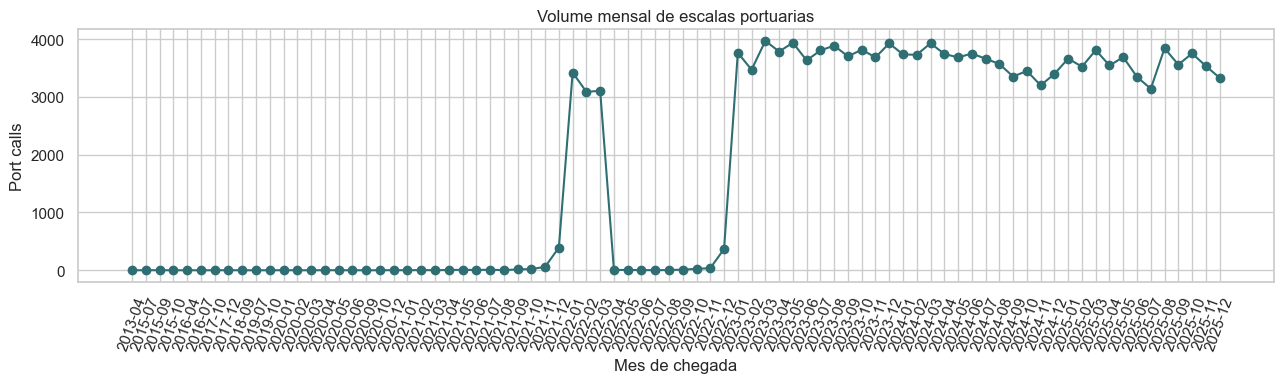

In [24]:
if "arrival_port_ts" in df.columns:
    print("Inicio:", df["arrival_port_ts"].min())
    print("Fim:", df["arrival_port_ts"].max())
    df["arrival_month_period"] = df["arrival_port_ts"].dt.to_period("M").astype(str)
    monthly = df.groupby("arrival_month_period").size().reset_index(name="port_calls")
    display(monthly)

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(monthly["arrival_month_period"], monthly["port_calls"], marker="o", color="#2F6F73")
    ax.set_title("Volume mensal de escalas portuarias")
    ax.set_xlabel("Mes de chegada")
    ax.set_ylabel("Port calls")
    ax.tick_params(axis="x", rotation=70)
    savefig("eda_volume_mensal.png")
    plt.show()


## 8. Distribuicao dos targets

Os targets sao duracoes em horas: espera para atracacao, operacao, pos-operacao e estadia total. Como lead times portuarios tendem a ter cauda longa, avaliamos tambem a escala `log1p`.


,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
t_wait_for_berthing_h,"141,895.000",10.323,63.834,0.000,0.000,0.000,0.000,0.000,0.000,6.900,40.627,256.422,"3,000.950"
t_operation_h,"141,895.000",99.676,791.800,0.017,1.350,5.667,17.500,35.417,74.333,153.567,254.610,891.100,"77,638.717"
t_post_operation_h,"141,895.000",0.830,19.893,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,13.500,"3,958.167"
t_total_port_stay_h,"141,895.000",110.829,795.278,0.017,1.750,6.333,19.083,39.350,85.250,183.550,313.583,994.842,"77,638.717"
t_wait_for_berthing_d,"141,895.000",0.430,2.660,0.000,0.000,0.000,0.000,0.000,0.000,0.288,1.693,10.684,125.040
t_operation_d,"141,895.000",4.153,32.992,0.001,0.056,0.236,0.729,1.476,3.097,6.399,10.609,37.129,"3,234.947"
t_post_operation_d,"141,895.000",0.035,0.829,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.562,164.924
t_total_port_stay_d,"141,895.000",4.618,33.137,0.001,0.073,0.264,0.795,1.640,3.552,7.648,13.066,41.452,"3,234.947"


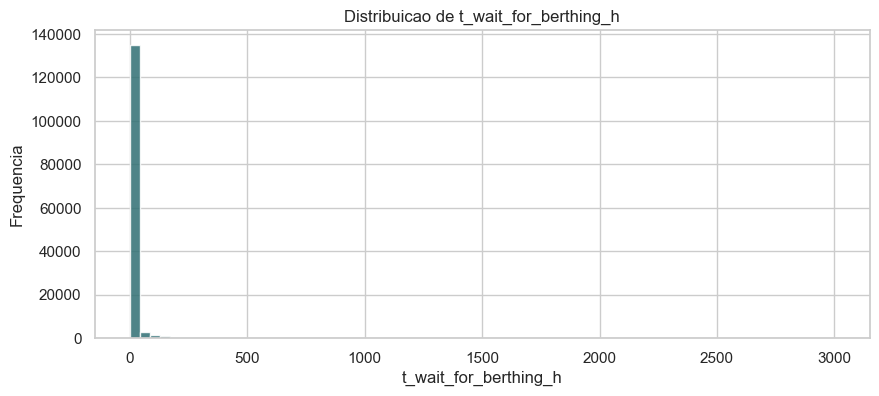

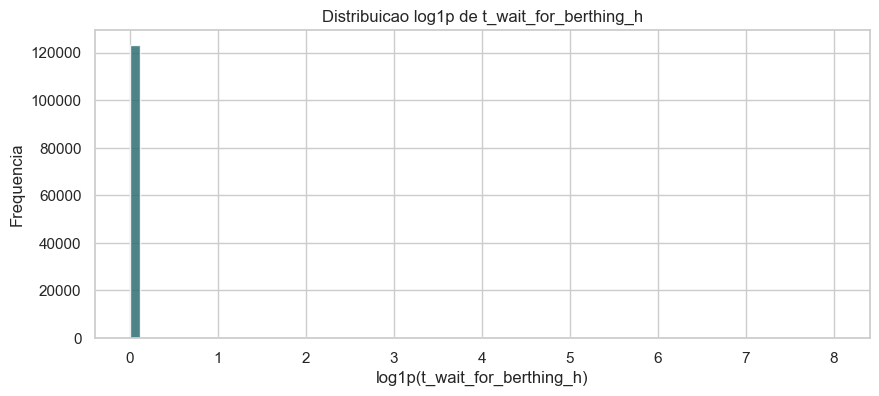

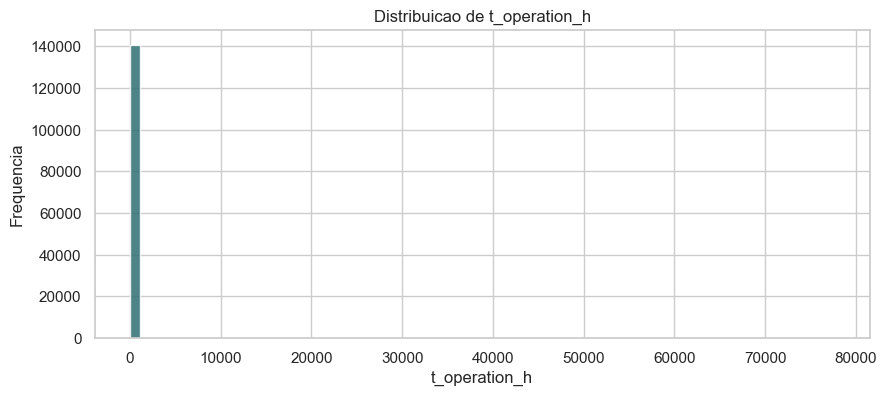

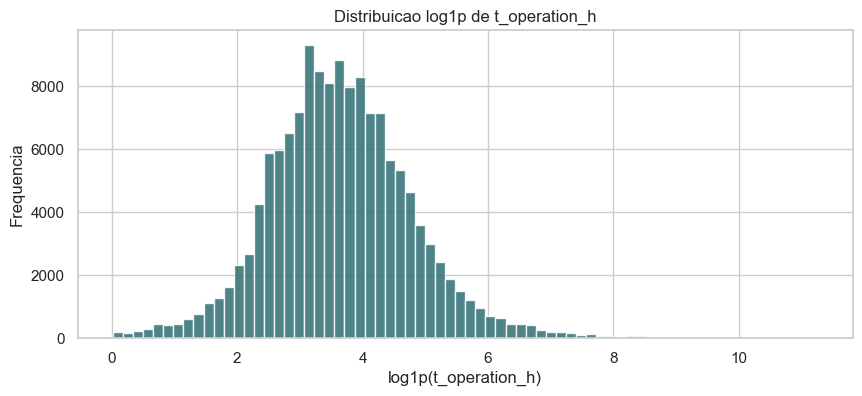

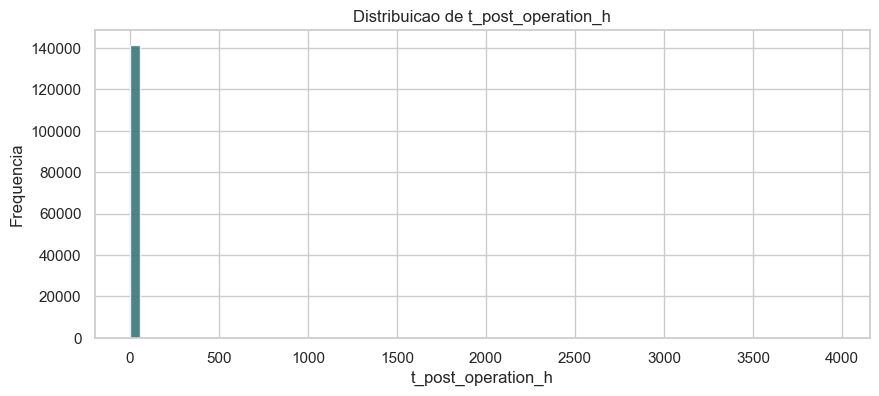

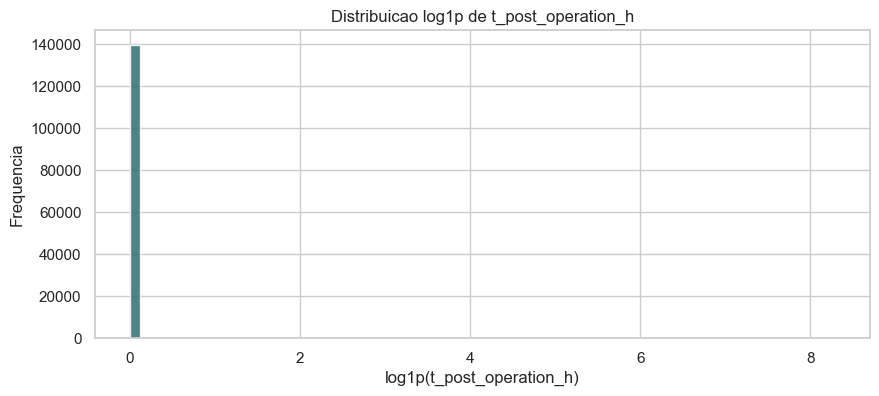

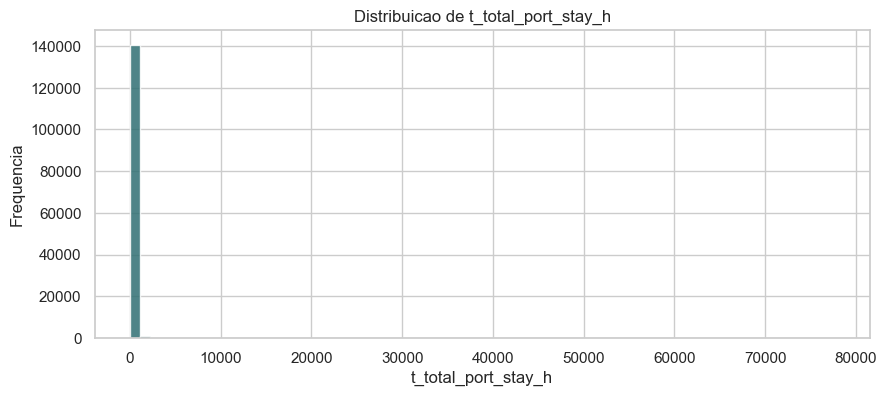

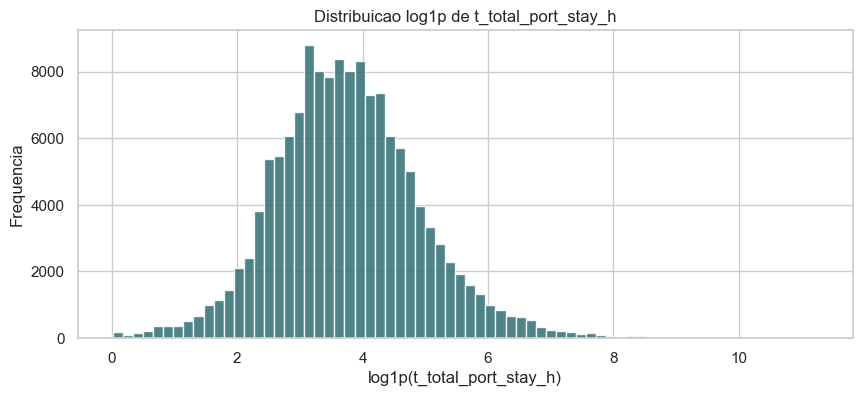

In [25]:
target_cols = existing(TARGETS_H + TARGETS_D, df)
display(numeric_summary(df, target_cols))

for col in existing(TARGETS_H, df):
    plot_hist(df, col, bins=70, log_x=False, title=f"Distribuicao de {col}")
    plot_hist(df, col, bins=70, log_x=True, title=f"Distribuicao log1p de {col}")

numeric_summary(df, target_cols).to_csv(TABLES_DIR / "eda_target_summary.csv")


## 9. Composicao da estadia total

A estadia total e a soma de espera, operacao e pos-operacao. Esta secao mede a participacao media de cada componente e identifica onde o tempo e consumido.


,count,mean,std,min,25%,50%,75%,90%,max
t_wait_for_berthing_h,"141,895.000",0.059,0.182,0.000,0.000,0.000,0.000,0.183,0.999
t_operation_h,"141,895.000",0.936,0.190,0.001,1.000,1.000,1.000,1.000,1.000
t_post_operation_h,"141,895.000",0.006,0.055,0.000,0.000,0.000,0.000,0.000,0.998


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction\outputs\figures\eda_componentes_estadia_media.png


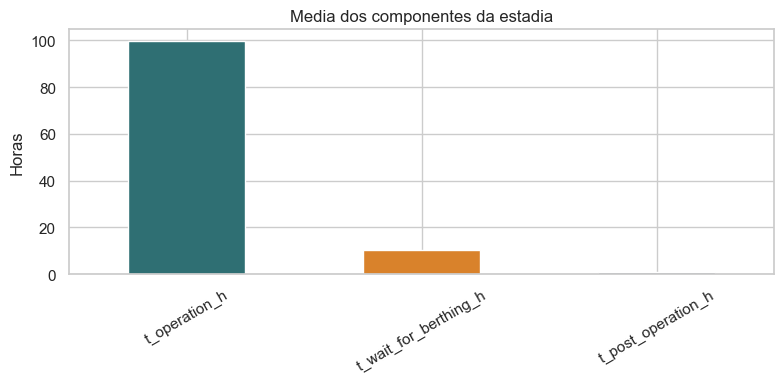

In [26]:
component_cols = existing(["t_wait_for_berthing_h", "t_operation_h", "t_post_operation_h"], df)
if component_cols and "t_total_port_stay_h" in df.columns:
    component_share = df[component_cols].div(df["t_total_port_stay_h"].replace(0, np.nan), axis=0)
    share_summary = component_share.describe(percentiles=[0.25, 0.5, 0.75, 0.9]).T
    display(share_summary)

    mean_components = df[component_cols].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    mean_components.plot(kind="bar", ax=ax, color=["#2F6F73", "#D9822B", "#6B7280"])
    ax.set_title("Media dos componentes da estadia")
    ax.set_ylabel("Horas")
    ax.tick_params(axis="x", rotation=30)
    savefig("eda_componentes_estadia_media.png")
    plt.show()


## 10. Analise por porto, estado e regiao

O objetivo aqui e separar volume de severidade. Portos com muitos registros e mediana alta merecem atencao diferente de portos pequenos com poucos casos extremos.



Resumo por port_display_ref


,port_display_ref,n,mean,median,p75,p90,max
101,BRVDC005 - TERMINAL DA NAVEGAÇÕES UNIDAS TAPAJ...,198,269.180,215.750,380.300,515.295,969.000
112,BRVIX026 - ESTALEIRO JURONG - BARRA DO SAHY - ...,87,467.819,143.250,241.658,491.333,"5,787.333"
51,BRMAO017 - TERMINAL FLUVIAL DISTRIBUIDORA ATEM´S,74,153.291,128.067,187.700,291.478,548.267
32,BRITA001 - TERMINAL HERMASA DA AMAZÔNIA LTDA,459,178.427,123.900,206.283,332.270,"1,589.367"
39,BRITJ002 - TERMINAL DA BRASKARNE,64,130.061,116.500,162.258,268.928,367.200
12,BRANT - PORTO DE ANTONINA,277,137.531,115.800,161.250,234.073,"1,361.383"
52,BRMCP - TERMINAL FLUVIAL DE SANTANA,312,101.019,111.450,147.471,171.807,334.617
87,BRSSA004 - TMG-ITAPUA - TERMINAL MARITIMO DE G...,135,125.734,108.333,178.117,229.780,695.333
50,BRMAO007 - CIMENTO VENCEMOS DO AMAZONAS,40,126.234,107.000,118.400,127.950,545.000
83,BRSFS - PORTO DE SÃO FRANCISCO DO SUL,1554,261.666,105.383,274.629,568.583,"5,764.000"



Resumo por port_display


,port_display,n,mean,median,p75,p90,max
124,BRVDC005 - TERFRON - TERMINAL FRONTEIRA NORTE ...,198,269.180,215.750,380.300,515.295,969.000
135,BRVIX026 - ESTALEIRO JURONG - BARRA DO SAHY - ...,87,467.819,143.250,241.658,491.333,"5,787.333"
41,BRITA001 - TERMINAL HERMASA DA AMAZÔNIA LTDA -...,427,181.528,130.467,206.283,342.160,"1,589.367"
67,BRMCP - SANTANA/MACAPA,231,117.265,122.450,148.450,172.150,334.617
50,BRITJ002 - TERMINAL DA BRASKARNE - ITAJAÍ - SC,61,135.166,122.167,163.383,269.683,367.200
64,BRMAO017 - ATEMŽS - MANAUS - AM,59,147.620,118.917,187.200,302.010,548.267
15,BRANT - ANTONINA,277,137.531,115.800,161.250,234.073,"1,361.383"
40,BRITA001 - HERMASA DA AMAZÔNIA - ITACOATIARA - AM,32,137.047,114.517,188.700,245.470,331.667
107,BRSSA004 - TMG-ITAPUA - TERMINAL MARITIMO DE G...,133,125.797,108.333,177.900,230.307,695.333
63,BRMAO007 - CIMENTO VENCEMOS DO AMAZONAS - MANA...,40,126.234,107.000,118.400,127.950,545.000



Resumo por port


...


Resumo por state


,state,n,mean,median,p75,p90,max
2,AP,312,101.019,111.450,147.471,171.807,334.617
1,AM,2224,113.124,70.850,121.875,232.440,"1,589.367"
15,SE,208,92.506,65.250,118.275,169.023,739.000
8,PB,336,114.818,55.067,95.733,120.283,"7,520.000"
9,PE,6101,198.761,54.433,126.167,231.167,"39,078.917"
6,MA,5270,72.099,50.483,72.479,115.313,"1,722.667"
16,SP,19907,125.281,49.333,118.600,299.080,"22,802.083"
7,PA,6921,80.297,46.967,94.817,177.000,"1,677.167"
5,ES,6142,73.399,42.342,71.158,117.878,"69,955.600"
4,CE,4383,214.244,41.550,106.300,239.380,"77,638.717"



Resumo por region


,region,n,mean,median,p75,p90,max
1,NORTE,9457,88.701,55.383,103.750,190.367,"1,677.167"
2,SUDESTE,76417,122.886,41.083,90.833,208.500,"74,652.500"
0,NORDESTE,27777,113.627,38.683,77.917,160.033,"77,638.717"
3,SUL,28244,82.867,29.567,71.087,146.000,"33,978.500"


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction\outputs\figures\eda_top_portos_mediana_estadia_total.png


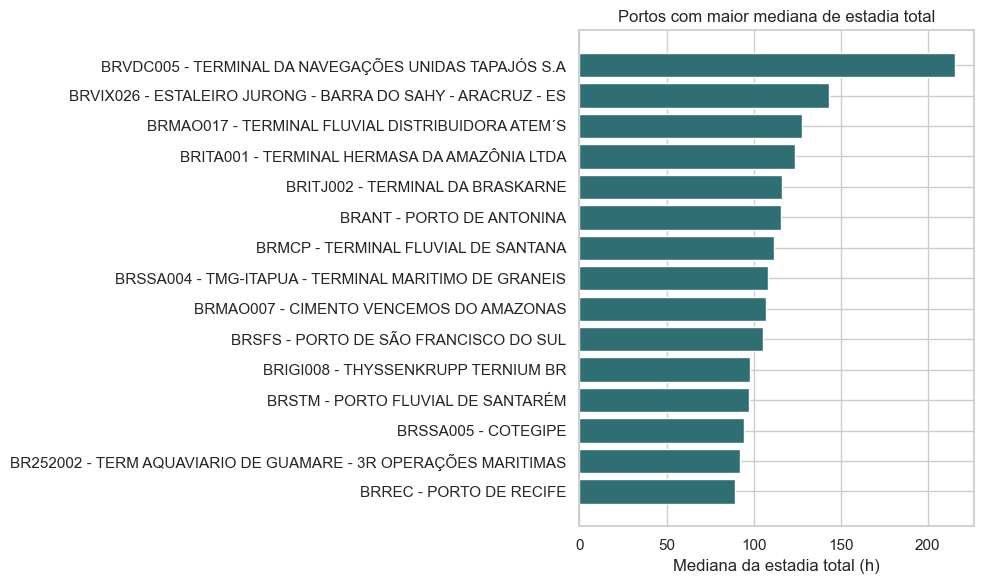

In [35]:
for group_col in existing(["port_display_ref", "port_display", "port", "state", "region"], df):
    summary = group_target_summary(df, group_col, target="t_total_port_stay_h", min_n=20)
    if not summary.empty:
        print(f"\nResumo por {group_col}")
        display(summary.head(20))
        summary.to_csv(TABLES_DIR / f"eda_total_stay_by_{group_col}.csv", index=False)

best_port_col = "port_display_ref" if "port_display_ref" in df.columns else ("port_display" if "port_display" in df.columns else "port")
if best_port_col in df.columns and "t_total_port_stay_h" in df.columns:
    top_ports = group_target_summary(df, best_port_col, "t_total_port_stay_h", min_n=20).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_ports[best_port_col].astype(str), top_ports["median"], color="#2F6F73")
    ax.invert_yaxis()
    ax.set_title("Portos com maior mediana de estadia total")
    ax.set_xlabel("Mediana da estadia total (h)")
    savefig("eda_top_portos_mediana_estadia_total.png")
    plt.show()


## 11. Tipo de operacao, rotas e embarcacoes

Esta etapa procura heterogeneidade operacional. Alem da coluna textual `operation_type`, a base agora contem flags booleanas `op_*` derivadas do parser de tipos de operacao. Elas permitem avaliar operacoes multi-rotulo como `Carga e Descarga`, `Abastecimento (Bunker),Arribada` ou textos concatenados sem separador.



Resumo por operation_type


,operation_type,n,mean,median,p75,p90,max
205,Reparo/Manutenção,86,606.852,433.633,"1,034.117","1,249.542","2,194.417"
3,"Abastecimento (Bunker),Arribada,Carga e Descar...",34,118.843,117.125,138.167,179.508,267.067
12,"Abastecimento (Bunker),Arribada,Carga,Carga e ...",21,132.099,110.967,158.500,201.000,372.067
13,"Abastecimento (Bunker),Arribada,Carga,Carga e ...",28,85.566,94.542,103.604,122.300,161.400
4,"Abastecimento (Bunker),Arribada,Carga e Descar...",82,119.678,92.792,142.996,241.550,438.833
21,"Abastecimento (Bunker),Carga e Descarga",104,138.151,62.650,147.804,226.920,"2,327.083"
20,"Abastecimento (Bunker),Carga",249,105.142,61.417,111.700,194.653,"2,225.200"
112,Carga,34204,106.729,60.533,111.587,222.597,"22,802.083"
131,"Carga,Descarga",97,103.234,57.700,164.167,246.403,508.967
142,Descarga,27550,107.172,57.092,116.000,224.833,"69,955.600"



Resumo por source_port_display


,source_port_display,n,mean,median,p75,p90,max
1273,USPDX - PORTLAND (MAINE),36,390.299,295.667,654.017,853.967,"1,193.867"
1092,SARTA - RAS TANURA,27,282.373,293.000,418.175,527.670,655.000
1064,QAMES - MESAIEED,24,329.971,186.150,385.788,956.613,"1,356.767"
729,ILASH - ASHDOD,53,250.166,167.167,295.917,500.890,"1,265.083"
1077,RUNVS - NOVOROSSIYSK,38,233.449,164.300,308.875,550.197,838.417
96,BHSIT - SITRA,20,415.200,158.758,450.917,"1,090.975","1,942.200"
956,NGLEI - LEKKI,33,308.878,158.500,324.333,966.667,"1,111.150"
315,CAVAN - VANCOUVER,118,252.292,155.233,359.763,557.675,"1,284.083"
308,CASJB - SAINT JOHN,63,256.905,154.467,276.133,561.917,"1,208.917"
1262,USNNS - NEWPORT NEWS,37,233.627,154.250,336.750,459.063,"1,172.433"



Resumo por destination_port_display


...


Resumo por imo


,imo,n,mean,median,p75,p90,max
8784,9727742,6,"10,121.661","8,101.183","18,496.792","20,531.833","20,531.833"
7657,9679153,5,"5,526.140","4,182.833","4,396.000","11,358.920","16,000.867"
12156,9956226,5,"3,408.770","3,956.450","4,092.833","7,000.983","8,939.750"
274,8650409,5,"3,352.283","3,952.000","4,455.450","4,460.580","4,464.000"
10192,9819624,6,"3,107.844","3,851.000","4,291.738","4,380.833","4,464.000"
3784,9449144,10,"4,691.405","3,109.167","7,760.488","9,063.085","14,590.000"
1692,9307968,8,"3,780.052","2,462.983","4,685.833","8,581.983","15,045.667"
282,8663585,7,"3,254.195","1,881.417","4,323.458","6,901.850","9,840.000"
1687,9307695,12,"7,453.943","1,770.042","14,197.179","22,742.572","23,333.000"
3780,9449077,9,"2,027.237","1,439.000","2,839.100","4,792.920","6,694.000"



Resumo por vessel_name


,vessel_name,n,mean,median,p75,p90,max
12049,SVITZER MARIA DARIAN,6,"10,121.661","8,101.183","18,496.792","20,531.833","20,531.833"
13300,WS VIRGO,10,"5,496.297","4,425.433","5,214.942","7,791.570","15,109.800"
13282,WS ANTARES,5,"5,526.140","4,182.833","4,396.000","11,358.920","16,000.867"
12036,SVITZER ARTHUR,5,"3,408.770","3,956.450","4,092.833","7,000.983","8,939.750"
8615,NJOERD,5,"3,352.283","3,952.000","4,455.450","4,460.580","4,464.000"
12042,SVITZER DENISE,6,"3,107.844","3,851.000","4,291.738","4,380.833","4,464.000"
5797,HUMBERTO,10,"2,912.788","3,351.733","4,533.496","5,889.193","6,268.333"
10319,SAAM TERENA,10,"4,691.405","3,109.167","7,760.488","9,063.085","14,590.000"
13283,WS AQUILA,8,"3,780.052","2,462.983","4,685.833","8,581.983","15,045.667"
6924,LOCAR XII,8,"5,776.163","2,377.308","11,886.013","15,258.500","15,258.500"


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction\outputs\figures\eda_operacao_mediana_estadia_total.png


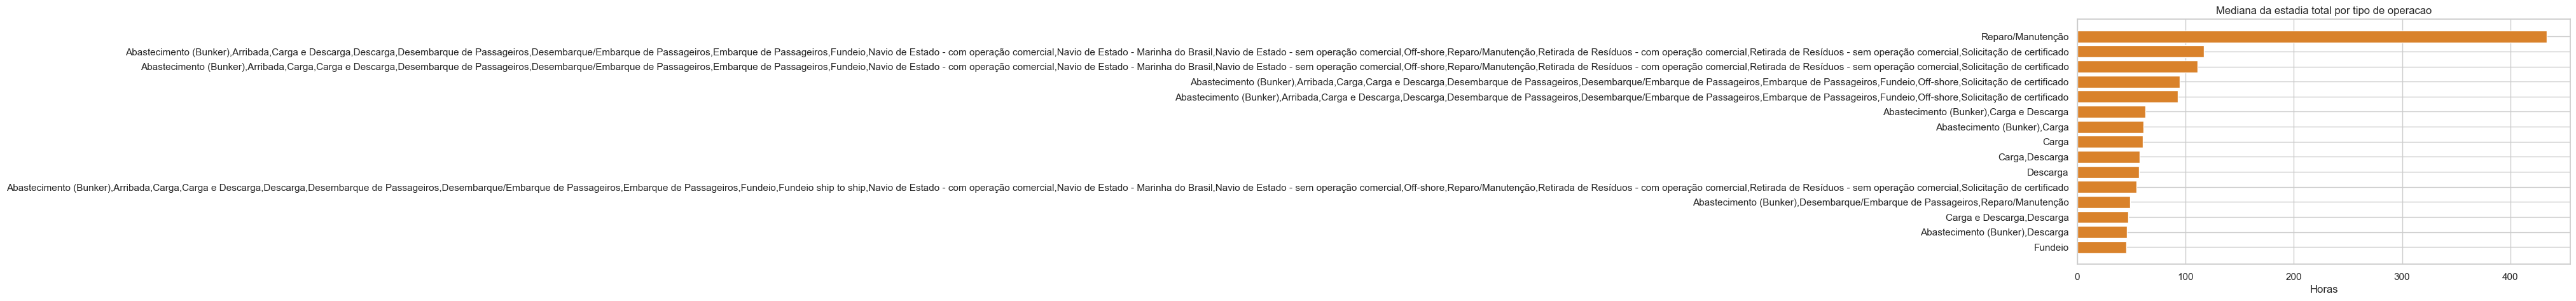

In [28]:
candidate_groups = existing(["operation_type", "source_port_display", "destination_port_display", "source_port", "destination_port", "imo", "vessel_name"], df)

for group_col in candidate_groups:
    min_n = 20 if group_col not in ["imo", "vessel_name"] else 5
    summary = group_target_summary(df, group_col, target="t_total_port_stay_h", min_n=min_n)
    if not summary.empty:
        print(f"\nResumo por {group_col}")
        display(summary.head(15))

if "operation_type" in df.columns and "t_total_port_stay_h" in df.columns:
    op = group_target_summary(df, "operation_type", "t_total_port_stay_h", min_n=20).head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(op["operation_type"].astype(str), op["median"], color="#D9822B")
    ax.invert_yaxis()
    ax.set_title("Mediana da estadia total por tipo de operacao")
    ax.set_xlabel("Horas")
    savefig("eda_operacao_mediana_estadia_total.png")
    plt.show()

operation_flag_cols = [col for col in df.columns if col.startswith(OPERATION_FLAG_PREFIX)]
operation_signal_cols = [col for col in operation_flag_cols if col != OPERATION_UNMAPPED_COL]

if operation_flag_cols:
    operation_freq = (
        pd.DataFrame({
            "operation_flag": operation_flag_cols,
            "n_true": [int(df[col].fillna(False).astype(bool).sum()) for col in operation_flag_cols],
            "pct_true": [df[col].fillna(False).astype(bool).mean() * 100 for col in operation_flag_cols],
        })
        .sort_values("n_true", ascending=False)
        .reset_index(drop=True)
    )
    display(operation_freq)
    operation_freq.to_csv(TABLES_DIR / "eda_operation_flag_frequency.csv", index=False)

operation_target_rows = []
for flag_col in operation_signal_cols:
    flag = df[flag_col].fillna(False).astype(bool)
    for target in existing(TARGETS_H, df):
        target_true = df.loc[flag, target].dropna()
        target_false = df.loc[~flag, target].dropna()
        if len(target_true) < 20 or len(target_false) < 20:
            continue
        operation_target_rows.append({
            "operation_flag": flag_col,
            "target": target,
            "n_true": len(target_true),
            "pct_true": flag.mean() * 100,
            "median_true": target_true.median(),
            "median_false": target_false.median(),
            "median_diff": target_true.median() - target_false.median(),
            "mean_true": target_true.mean(),
            "mean_false": target_false.mean(),
            "mean_diff": target_true.mean() - target_false.mean(),
            "corr": flag.astype(int).corr(df[target]),
        })

operation_target_summary = pd.DataFrame(operation_target_rows)
if not operation_target_summary.empty:
    operation_target_summary["abs_median_diff"] = operation_target_summary["median_diff"].abs()
    operation_target_summary["abs_corr"] = operation_target_summary["corr"].abs()
    operation_target_summary = operation_target_summary.sort_values(
        ["target", "abs_median_diff", "abs_corr"],
        ascending=[True, False, False],
    ).reset_index(drop=True)
    display(operation_target_summary)
    operation_target_summary.to_csv(TABLES_DIR / "eda_operation_flags_target_summary.csv", index=False)

    for target in existing(["t_wait_for_berthing_h", "t_operation_h", "t_total_port_stay_h"], df):
        plot_data = (
            operation_target_summary.query("target == @target")
            .sort_values("abs_median_diff", ascending=False)
            .head(12)
            .sort_values("median_diff")
        )
        if plot_data.empty:
            continue
        colors = np.where(plot_data["median_diff"] >= 0, "#2F6F73", "#D9822B")
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh(plot_data["operation_flag"], plot_data["median_diff"], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"Diferenca de mediana por flag de operacao - {target}")
        ax.set_xlabel("Horas: mediana com flag - mediana sem flag")
        savefig(f"eda_operation_flags_median_diff_{target}.png")
        plt.show()

if OPERATION_UNMAPPED_COL in df.columns:
    print("Registros com operation_type nao mapeado:", int(df[OPERATION_UNMAPPED_COL].fillna(False).astype(bool).sum()))


## 12. Sazonalidade e calendario

As features de calendario derivam de `arrival_port_ts`: ano, mes, trimestre, semana, dia, dia da semana, hora, turno, fim de semana e estacao do ano no hemisferio sul.



Resumo por arrival_year


,arrival_year,n,mean,median,p75,p90,max
6,2020,14,"21,733.348","17,904.358","27,862.458","37,675.300","40,315.833"
7,2021,530,"1,872.976",462.450,"1,591.338","3,950.400","38,595.250"
10,2024,43184,93.873,40.417,85.833,178.068,"15,780.433"
8,2022,10078,154.240,39.333,94.812,227.252,"23,213.267"
11,2025,42715,81.526,39.267,82.667,166.367,"7,200.750"
9,2023,45360,99.557,37.750,83.250,188.205,"22,802.083"



Resumo por arrival_month


,arrival_month,n,mean,median,p75,p90,max
11,12,11418,125.777,42.717,95.429,214.350,"48,724.500"
6,7,10621,129.782,41.750,87.583,192.000,"70,032.067"
7,8,11301,103.185,41.667,86.167,191.117,"17,708.783"
8,9,10639,129.644,41.167,87.500,194.163,"71,851.417"
5,6,10732,100.634,41.000,85.267,180.300,"38,595.250"
10,11,10512,113.475,40.575,85.713,180.392,"15,979.333"
9,10,11065,119.980,40.367,87.000,194.987,"67,945.867"
4,5,11320,108.806,39.833,83.667,177.208,"28,327.000"
3,4,11086,122.463,37.200,82.442,168.908,"77,638.717"
1,2,13811,103.936,36.500,81.950,176.000,"34,148.250"



Resumo por arrival_quarter


...


Resumo por arrival_season


,arrival_season,n,mean,median,p75,p90,max
3,winter,32654,110.998,41.450,86.333,187.912,"70,032.067"
1,spring,32216,121.049,40.667,86.583,189.292,"71,851.417"
2,summer,39809,108.434,38.000,85.917,187.847,"48,724.500"
0,autumn,37216,104.397,37.583,82.200,170.000,"77,638.717"



Resumo por arrival_is_weekend


,arrival_is_weekend,n,mean,median,p75,p90,max
1,1,36764,108.753,39.917,87.071,182.485,"71,851.417"
0,0,105131,111.556,39.167,84.500,184.000,"77,638.717"


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction\outputs\figures\eda_sazonalidade_mensal_estadia_total.png


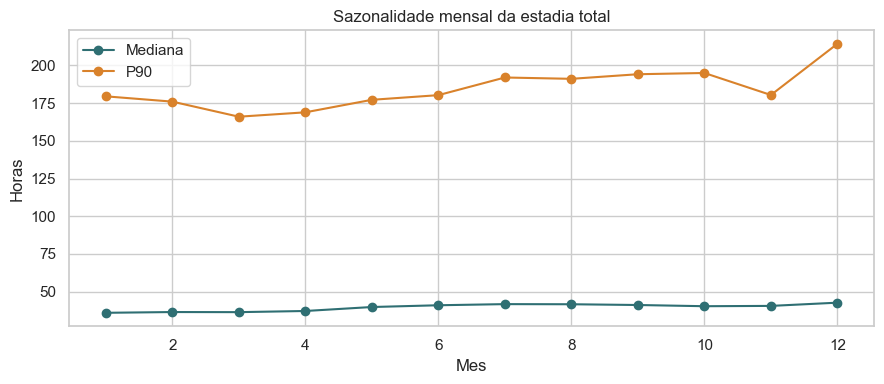

In [29]:
calendar_groups = existing(["arrival_year", "arrival_month", "arrival_quarter", "arrival_dayofweek", "arrival_hour", "arrival_shift", "arrival_season", "arrival_is_weekend"], df)

for group_col in calendar_groups:
    summary = group_target_summary(df, group_col, target="t_total_port_stay_h", min_n=10)
    if not summary.empty:
        print(f"\nResumo por {group_col}")
        display(summary)

if "arrival_month" in df.columns and "t_total_port_stay_h" in df.columns:
    monthly_target = df.groupby("arrival_month")["t_total_port_stay_h"].agg(n="count", median="median", p90=lambda s: s.quantile(0.90)).reset_index()
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(monthly_target["arrival_month"], monthly_target["median"], marker="o", label="Mediana", color="#2F6F73")
    ax.plot(monthly_target["arrival_month"], monthly_target["p90"], marker="o", label="P90", color="#D9822B")
    ax.set_title("Sazonalidade mensal da estadia total")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Horas")
    ax.legend()
    savefig("eda_sazonalidade_mensal_estadia_total.png")
    plt.show()


## 13. Congestionamento portuario

As proxies de congestionamento usam informacao historica por porto: medias e desvios das 20 chamadas anteriores e chegadas no mesmo dia/dia anterior/media dos 7 dias anteriores. Elas devem ser avaliadas tanto por cobertura quanto por associacao com os targets.


,column,dtype,missing_n,missing_pct,unique_n
0,avg_wait_prev_20_calls_port,float64,550,0.388,25655
1,avg_operation_prev_20_calls_port,float64,550,0.388,123030
2,std_wait_prev_20_calls_port,float64,550,0.388,26885
3,arrivals_prev_7d_avg_port,float64,381,0.269,209
4,arrivals_prev_day_port,float64,124,0.087,41
5,arrivals_same_day_port,int64,0,0.000,41


,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
avg_wait_prev_20_calls_port,"141,345.000",10.393,33.482,0.000,0.000,0.000,0.000,0.000,7.010,30.872,56.965,131.713,"1,571.450"
avg_operation_prev_20_calls_port,"141,345.000",105.996,721.741,1.208,7.527,16.242,41.774,63.264,96.643,152.367,217.164,507.575,"71,266.653"
std_wait_prev_20_calls_port,"141,345.000",20.358,52.812,0.000,0.000,0.000,0.000,0.000,15.514,65.827,115.736,231.362,"1,184.424"
arrivals_same_day_port,"141,895.000",9.169,8.924,1.000,1.000,1.000,2.000,5.000,16.000,23.000,27.000,33.000,41.000
arrivals_prev_day_port,"141,771.000",8.436,8.653,1.000,1.000,1.000,2.000,4.000,15.000,22.000,26.000,32.000,41.000
arrivals_prev_7d_avg_port,"141,514.000",8.395,8.069,1.000,1.000,1.000,1.714,4.000,14.571,22.000,23.571,25.571,29.857


,t_wait_for_berthing_h,t_operation_h,t_post_operation_h,t_total_port_stay_h
avg_operation_prev_20_calls_port,0.032,0.605,0.001,0.602
avg_wait_prev_20_calls_port,0.416,0.008,-0.003,0.059
std_wait_prev_20_calls_port,0.385,0.003,-0.003,0.051
arrivals_prev_7d_avg_port,0.006,0.013,0.027,0.015
arrivals_prev_day_port,0.006,0.005,0.026,0.006
arrivals_same_day_port,0.008,0.001,0.027,0.003


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction\outputs\figures\eda_correlacao_congestionamento_targets.png


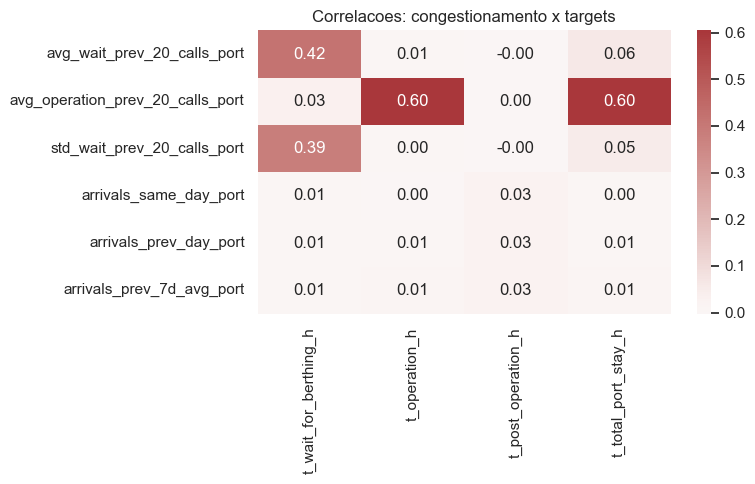

In [30]:
congestion_cols = existing(CONGESTION_COLS, df)
display(missing_table(df[congestion_cols]) if congestion_cols else pd.DataFrame())
display(numeric_summary(df, congestion_cols))

if congestion_cols and "t_total_port_stay_h" in df.columns:
    corr = df[congestion_cols + existing(TARGETS_H, df)].corr(numeric_only=True).loc[congestion_cols, existing(TARGETS_H, df)]
    display(corr.sort_values("t_total_port_stay_h", ascending=False) if "t_total_port_stay_h" in corr.columns else corr)

    if sns is not None:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
        ax.set_title("Correlacoes: congestionamento x targets")
        savefig("eda_correlacao_congestionamento_targets.png")
        plt.show()


## 14. Clima e cobertura meteorologica

A base meteorologica e ligada ao porto por coordenadas arredondadas e data de chegada. Primeiro avaliamos cobertura; depois, associacoes simples entre chuva, vento, temperatura e lead time.


,has_port_reference,has_weather_data
1,141895,141895


,column,dtype,missing_n,missing_pct,unique_n
0,rain_sum_prev_1d,float64,3,0.002,675
1,precipitation_sum_prev_1d,float64,3,0.002,675
2,wind_speed_10m_max_prev_1d,float64,3,0.002,478
3,wind_gusts_10m_max_prev_1d,float64,3,0.002,197
4,temperature_2m_mean_prev_1d,float64,3,0.002,253
5,rain_sum_prev_3d,float64,3,0.002,13425
6,precipitation_hours_prev_3d,float64,3,0.002,73
7,temperature_2m_mean_prev_3d,float64,3,0.002,2166
8,wind_speed_10m_max_prev_3d,float64,3,0.002,465
9,wind_gusts_10m_max_prev_3d,float64,3,0.002,194


,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
temperature_2m_mean,"141,895.000",24.237,3.308,5.700,13.600,18.100,22.300,25.000,26.700,27.700,28.200,29.400,32.500
temperature_2m_max,"141,895.000",26.646,3.758,8.800,15.500,19.900,24.500,27.100,29.100,31.000,32.100,34.200,39.100
temperature_2m_min,"141,895.000",22.247,3.381,2.200,11.400,15.900,20.200,23.100,24.800,25.800,26.300,27.000,28.700
precipitation_sum,"141,895.000",3.727,8.320,0.000,0.000,0.000,0.000,0.700,3.600,11.000,17.700,37.700,229.600
rain_sum,"141,895.000",3.727,8.320,0.000,0.000,0.000,0.000,0.700,3.600,11.000,17.700,37.700,229.600
precipitation_hours,"141,895.000",7.055,7.672,0.000,0.000,0.000,0.000,4.000,12.000,20.000,23.000,24.000,24.000
wind_speed_10m_max,"141,895.000",19.473,6.994,3.400,7.900,10.100,14.400,18.400,23.300,29.000,33.000,40.100,61.600
wind_gusts_10m_max,"141,895.000",32.215,8.726,11.500,16.900,20.200,25.900,31.000,37.100,44.300,48.600,56.900,95.000
wind_direction_10m_dominant,"141,895.000",117.382,78.351,0.000,6.000,23.000,60.000,96.000,159.000,231.000,284.000,351.000,360.000
rain_sum_prev_1d,"141,892.000",3.776,8.558,0.000,0.000,0.000,0.000,0.700,3.700,11.100,17.900,38.000,229.600


,t_wait_for_berthing_h,t_operation_h,t_post_operation_h,t_total_port_stay_h
wind_direction_10m_dominant,0.023,0.003,0.002,0.005
precipitation_hours_prev_7d,0.023,-0.001,-0.013,0.001
precipitation_sum,0.022,-0.001,-0.003,0.000
rain_sum,0.022,-0.001,-0.003,0.000
rain_sum_prev_1d,0.017,-0.001,-0.003,-0.000
precipitation_sum_prev_1d,0.017,-0.001,-0.003,-0.000
precipitation_hours,0.018,-0.002,-0.006,-0.000
temperature_2m_mean_prev_3d,-0.039,0.003,-0.003,-0.000
temperature_2m_mean_prev_1d,-0.038,0.003,-0.003,-0.000
temperature_2m_max,-0.059,0.004,0.001,-0.001


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction\outputs\figures\eda_correlacao_clima_targets.png


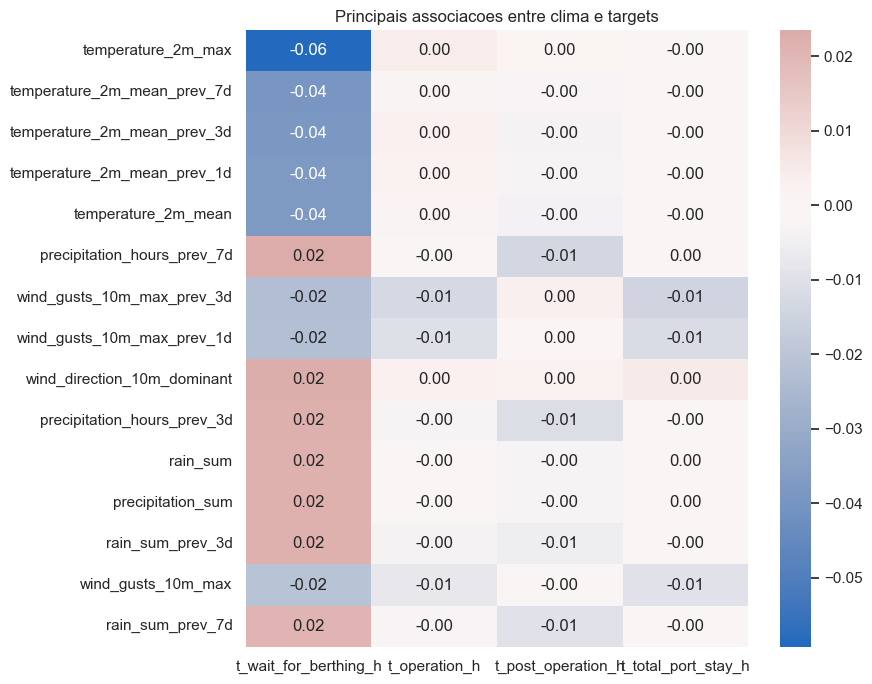

In [31]:
coverage_cols = existing(["has_port_reference", "has_weather_data"], df)
if coverage_cols:
    coverage = df[coverage_cols].apply(lambda s: s.value_counts(dropna=False)).fillna(0).astype(int)
    display(coverage)

weather_cols = existing(WEATHER_COLS, df)
display(missing_table(df[weather_cols]).head(40) if weather_cols else pd.DataFrame())
display(numeric_summary(df, weather_cols).head(40) if weather_cols else pd.DataFrame())

if weather_cols and existing(TARGETS_H, df):
    weather_corr = df[weather_cols + existing(TARGETS_H, df)].corr(numeric_only=True).loc[weather_cols, existing(TARGETS_H, df)]
    display(weather_corr.sort_values("t_total_port_stay_h", ascending=False) if "t_total_port_stay_h" in weather_corr.columns else weather_corr)
    weather_corr.to_csv(TABLES_DIR / "eda_weather_target_correlations.csv")

    if sns is not None:
        top_weather = weather_corr.abs().max(axis=1).sort_values(ascending=False).head(15).index.tolist()
        fig, ax = plt.subplots(figsize=(9, 7))
        sns.heatmap(weather_corr.loc[top_weather], annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
        ax.set_title("Principais associacoes entre clima e targets")
        savefig("eda_correlacao_clima_targets.png")
        plt.show()


## 15. Outliers e caudas longas

Lead time costuma ter cauda longa. Em vez de simplesmente remover extremos, esta etapa os identifica para decidir se representam eventos reais, erro de cadastro ou uma populacao operacional distinta.


In [32]:
outlier_rows = []
for col in existing(TARGETS_H, df):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    p99 = df[col].quantile(0.99)
    outlier_rows.append({
        "target": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "upper_iqr": q3 + 1.5 * iqr,
        "p99": p99,
        "n_above_upper_iqr": (df[col] > q3 + 1.5 * iqr).sum(),
        "n_above_p99": (df[col] > p99).sum(),
    })

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)
outlier_summary.to_csv(TABLES_DIR / "eda_outlier_summary.csv", index=False)

cols_to_show = existing(["port_call_id", "port", "port_display_ref", "operation_type", "arrival_port_ts"] + TARGETS_H + CONGESTION_COLS + WEATHER_COLS, df)
if "t_total_port_stay_h" in df.columns:
    display(df.sort_values("t_total_port_stay_h", ascending=False)[cols_to_show].head(30))


,target,q1,q3,iqr,upper_iqr,p99,n_above_upper_iqr,n_above_p99
0,t_wait_for_berthing_h,0.000,0.000,0.000,0.000,256.422,18569,1419
1,t_operation_h,17.500,74.333,56.833,159.583,891.100,13544,1418
2,t_post_operation_h,0.000,0.000,0.000,0.000,13.500,2245,1414
3,t_total_port_stay_h,19.083,85.250,66.167,184.500,994.842,14099,1419


,port_call_id,port,port_display_ref,operation_type,arrival_port_ts,t_wait_for_berthing_h,t_operation_h,t_post_operation_h,t_total_port_stay_h,avg_wait_prev_20_calls_port,avg_operation_prev_20_calls_port,std_wait_prev_20_calls_port,arrivals_same_day_port,arrivals_prev_day_port,arrivals_prev_7d_avg_port,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,rain_sum_prev_1d,precipitation_sum_prev_1d,wind_speed_10m_max_prev_1d,wind_gusts_10m_max_prev_1d,temperature_2m_mean_prev_1d,rain_sum_prev_3d,precipitation_hours_prev_3d,temperature_2m_mean_prev_3d,wind_speed_10m_max_prev_3d,wind_gusts_10m_max_prev_3d,rain_sum_prev_7d,precipitation_hours_prev_7d,temperature_2m_mean_prev_7d,wind_speed_10m_max_prev_7d,wind_gusts_10m_max_prev_7d
15168,105612013,BRFOR,BRFOR - PORTO DE FORTALEZA,Solicitação de certificado,2013-04-11 19:30:00,0.000,"77,638.717",0.000,"77,638.717",NaN,NaN,NaN,1,NaN,NaN,28.600,31.000,26.900,0.200,0.200,2.000,24.000,44.300,97,2.600,2.600,23.100,41.000,27.800,5.500,25.000,27.667,23.100,41.000,13.000,51.000,27.686,23.100,41.000
60401,110982016,BRRIO,BRRIO - PORTO DO RIO DE JANEIRO,Off-shore,2016-04-07 20:00:00,0.000,"74,652.500",0.000,"74,652.500",NaN,NaN,NaN,1,1.000,1.333,27.100,31.700,23.200,0.000,0.000,0.000,11.600,18.400,59,0.000,0.000,14.800,25.200,26.000,0.900,6.000,26.267,14.800,25.600,6.400,20.000,26.557,17.100,28.400
60399,537372023,BRRIO,BRRIO - PORTO DO RIO DE JANEIRO,Off-shore,2015-09-20 18:00:00,0.000,"71,851.417",0.000,"71,851.417",NaN,NaN,NaN,2,1.000,NaN,23.500,26.600,21.200,0.000,0.000,0.000,14.700,25.900,216,0.000,0.000,13.200,23.800,25.500,0.000,0.000,26.133,14.600,24.500,29.000,50.000,23.500,21.600,36.000
60398,331022015,BRRIO,BRRIO - PORTO DO RIO DE JANEIRO,Off-shore,2015-09-20 18:00:00,0.000,"71,851.417",0.000,"71,851.417",NaN,NaN,NaN,2,1.000,NaN,23.500,26.600,21.200,0.000,0.000,0.000,14.700,25.900,216,0.000,0.000,13.200,23.800,25.500,0.000,0.000,26.133,14.600,24.500,29.000,50.000,23.500,21.600,36.000
60397,291322015,BRRIO,BRRIO - PORTO DO RIO DE JANEIRO,<NA>,2015-07-10 17:00:00,0.000,"70,032.067",0.000,"70,032.067",NaN,NaN,NaN,1,NaN,NaN,22.100,26.000,18.700,0.000,0.000,0.000,20.200,35.300,88,0.000,0.000,9.700,18.400,22.800,0.000,0.000,22.133,14.800,26.600,13.300,32.000,21.343,24.100,44.600
135767,221152015,BRVIX,BRVIX - PORTO DE VITÓRIA,Descarga,2015-07-14 13:30:00,0.000,"69,955.600",0.000,"69,955.600",NaN,NaN,NaN,1,NaN,NaN,22.800,25.500,19.900,0.000,0.000,0.000,19.200,29.900,14,0.000,0.000,18.100,28.100,22.800,0.000,0.000,22.700,19.900,31.000,1.100,4.000,22.357,19.900,31.000
60400,432812016,BRRIO,BRRIO - PORTO DO RIO DE JANEIRO,<NA>,2015-10-05 15:10:00,0.000,"67,945.867",0.000,"67,945.867",NaN,NaN,NaN,1,2.000,NaN,21.300,22.200,20.600,2.100,2.100,9.000,18.300,29.200,159,11.400,11.400,19.500,38.900,22.600,11.400,18.000,24.433,22.700,40.000,15.500,31.000,24.271,22.700,42.800
60402,293412017,BRRIO,BRRIO - PORTO DO RIO DE JANEIRO,Off-shore,2016-07-02 06:50:00,0.000,"67,370.833",0.000,"67,370.833",0.000,"71,266.653",0.000,1,1.000,1.250,22.200,25.300,20.000,0.000,0.000,0.000,11.700,20.200,77,0.100,0.100,11.400,22.000,21.200,0.100,1.000,20.800,11.700,22.000,1.200,7.000,20.286,16.900,30.200
60403,286632018,BRRIO,BRRIO - PORTO DO RIO DE JANEIRO,Off-shore,2018-09-20 18:00:00,0.000,"49,238.667",0.000,"49,238.667",0.000,"70,617.350",0.000,1,1.000,1.200,24.800,27.000,22.600,0.000,0.000,0.000,13.400,20.900,94,0.000,0.000,11.800,22.000,25.500,9.300,10.000,23.233,15.800,28.800,30.200,32.000,22.486,28.100,47.200
34439,495682022,BRNTR,BRNTR - PORTO DE NITERÓI,Off-shore,2017-12-28 11:00:00,0.000,"48,724.500",0.000,"48,724.500",NaN,NaN,NaN,2,NaN,NaN,25.800,27.300,24.500,11.500,11.500,15.000,13.000,24.800,128,4.200,4.200,13.600,26.600,26.300,8.500,21.000,26.633,15.800,30.200,16.100,43.000,26.900,18.100,30.200


## 16. Matriz de correlacao geral

Esta matriz ajuda a detectar relacoes lineares, redundancias e possiveis features pouco informativas. Correlacao nao implica causalidade; use como triagem para investigacao e modelagem.


,t_wait_for_berthing_h,t_operation_h,t_post_operation_h,t_total_port_stay_h,avg_wait_prev_20_calls_port,avg_operation_prev_20_calls_port,std_wait_prev_20_calls_port,arrivals_same_day_port,arrivals_prev_day_port,arrivals_prev_7d_avg_port,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,rain_sum_prev_1d,precipitation_sum_prev_1d,wind_speed_10m_max_prev_1d,wind_gusts_10m_max_prev_1d,temperature_2m_mean_prev_1d,rain_sum_prev_3d,precipitation_hours_prev_3d,temperature_2m_mean_prev_3d,wind_speed_10m_max_prev_3d,wind_gusts_10m_max_prev_3d,rain_sum_prev_7d,precipitation_hours_prev_7d,temperature_2m_mean_prev_7d,wind_speed_10m_max_prev_7d,wind_gusts_10m_max_prev_7d,arrival_month,arrival_dayofweek,arrival_hour,arrival_is_weekend
t_wait_for_berthing_h,1.000,0.005,0.007,0.085,0.416,0.032,0.385,0.008,0.006,0.006,-0.038,-0.059,-0.017,0.022,0.022,0.018,0.005,-0.021,0.023,0.017,0.017,0.003,-0.023,-0.038,0.022,0.022,-0.039,0.006,-0.023,0.021,0.023,-0.040,0.008,-0.021,0.014,0.005,0.001,0.007
t_operation_h,0.005,1.000,0.017,0.996,0.008,0.605,0.003,0.001,0.005,0.013,0.002,0.004,-0.001,-0.001,-0.001,-0.002,-0.013,-0.008,0.003,-0.001,-0.001,-0.015,-0.010,0.003,-0.004,-0.003,0.003,-0.018,-0.013,-0.002,-0.001,0.001,-0.016,-0.010,0.010,-0.001,0.007,-0.002
t_post_operation_h,0.007,0.017,1.000,0.043,-0.003,0.001,-0.003,0.027,0.026,0.027,-0.004,0.001,-0.007,-0.003,-0.003,-0.006,-0.002,-0.001,0.002,-0.003,-0.003,0.001,0.001,-0.003,-0.006,-0.011,-0.003,0.002,0.003,-0.010,-0.013,-0.002,0.001,0.003,-0.003,0.002,0.001,0.003
t_total_port_stay_h,0.085,0.996,0.043,1.000,0.059,0.602,0.051,0.003,0.006,0.015,-0.001,-0.001,-0.003,0.000,0.000,-0.000,-0.013,-0.009,0.005,-0.000,-0.000,-0.015,-0.012,-0.000,-0.002,-0.001,-0.000,-0.018,-0.014,-0.001,0.001,-0.002,-0.015,-0.012,0.011,-0.000,0.007,-0.002
avg_wait_prev_20_calls_port,0.416,0.008,-0.003,0.059,1.000,0.030,0.886,0.012,0.009,0.011,-0.069,-0.110,-0.031,0.019,0.019,0.029,0.005,-0.045,0.045,0.035,0.035,0.008,-0.041,-0.070,0.037,0.039,-0.071,0.010,-0.047,0.040,0.043,-0.073,0.015,-0.042,0.027,0.002,0.001,0.005
avg_operation_prev_20_calls_port,0.032,0.605,0.001,0.602,0.030,1.000,0.018,-0.006,-0.006,-0.007,0.006,0.008,0.003,-0.004,-0.004,-0.002,-0.013,-0.004,-0.000,-0.003,-0.003,-0.015,-0.007,0.005,-0.003,-0.001,0.004,-0.019,-0.011,-0.001,-0.001,0.004,-0.017,-0.009,0.010,-0.002,-0.000,-0.004
std_wait_prev_20_calls_port,0.385,0.003,-0.003,0.051,0.886,0.018,1.000,0.031,0.027,0.030,-0.075,-0.124,-0.030,0.024,0.024,0.034,0.007,-0.056,0.054,0.041,0.041,0.010,-0.052,-0.077,0.047,0.050,-0.078,0.013,-0.058,0.055,0.058,-0.080,0.020,-0.053,0.012,0.004,0.003,0.010
arrivals_same_day_port,0.008,0.001,0.027,0.003,0.012,-0.006,0.031,1.000,0.887,0.928,-0.070,0.002,-0.126,-0.059,-0.059,-0.139,-0.084,-0.092,0.096,-0.055,-0.055,-0.095,-0.104,-0.073,-0.072,-0.163,-0.080,-0.047,-0.056,-0.084,-0.183,-0.082,-0.021,-0.024,-0.021,-0.067,-0.009,-0.083
arrivals_prev_day_port,0.006,0.005,0.026,0.006,0.009,-0.006,0.027,0.887,1.000,0.941,-0.067,0.005,-0.124,-0.042,-0.042,-0.125,-0.081,-0.082,0.093,-0.057,-0.057,-0.093,-0.098,-0.067,-0.077,-0.168,-0.074,-0.057,-0.064,-0.087,-0.187,-0.078,-0.031,-0.032,-0.019,-0.009,-0.008,-0.049
arrivals_prev_7d_avg_port,0.006,0.013,0.027,0.015,0.011,-0.007,0.030,0.928,0.941,1.000,-0.073,0.003,-0.133,-0.046,-0.046,-0.133,-0.085,-0.087,0.098,-0.048,-0.048,-0.091,-0.093,-0.072,-0.072,-0.170,-0.076,-0.049,-0.054,-0.094,-0.203,-0.079,-0.033,-0.036,-0.019,-0.017,-0.007,-0.020


g:\My Drive\Graduação e Pós\USP\MBA USP IA e Big Data\TCC\port_leadtime_prediction\outputs\figures\eda_matriz_correlacao.png


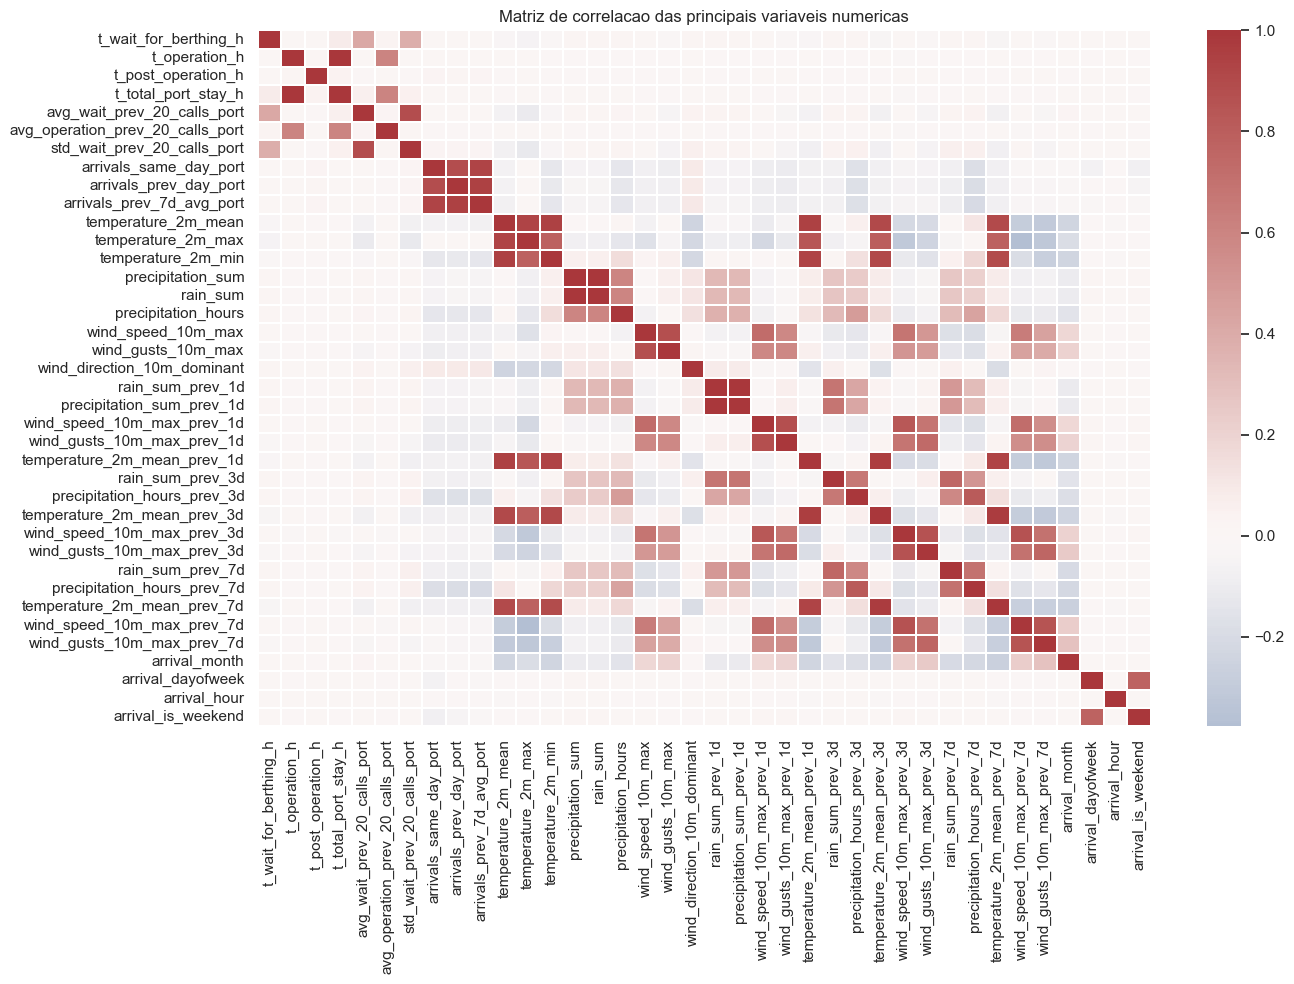

In [33]:
numeric_cols = df.select_dtypes(include=["number", "bool"]).columns.tolist()
operation_flag_cols = [col for col in df.columns if col.startswith(OPERATION_FLAG_PREFIX)]
candidate_numeric = existing(TARGETS_H + CONGESTION_COLS + WEATHER_COLS + operation_flag_cols + ["arrival_month", "arrival_dayofweek", "arrival_hour", "arrival_is_weekend"], df)
candidate_numeric = [col for col in candidate_numeric if col in numeric_cols]

if candidate_numeric:
    corr_matrix = df[candidate_numeric].corr(numeric_only=True)
    display(corr_matrix)
    corr_matrix.to_csv(TABLES_DIR / "eda_correlation_matrix.csv")

    if sns is not None:
        fig, ax = plt.subplots(figsize=(14, 10))
        sns.heatmap(corr_matrix, cmap="vlag", center=0, linewidths=0.2, ax=ax)
        ax.set_title("Matriz de correlacao das principais variaveis numericas")
        savefig("eda_matriz_correlacao.png")
        plt.show()


## 17. Checks de risco para modelagem

Use estes checks antes de treinar modelos. A ideia e separar variaveis disponiveis antes da predicao de variaveis que podem conter informacao do futuro ou definicoes diretamente derivadas do target.


In [34]:
potential_leakage_patterns = ["target", "total_port_stay", "operation_h", "post_operation", "log_t_", "_high", "_extreme"]
potential_leakage_cols = [
    col for col in df.columns
    if any(pattern in col for pattern in potential_leakage_patterns)
]

model_candidate_cols = [
    col for col in df.columns
    if col not in potential_leakage_cols
    and col not in existing(TARGETS_H + TARGETS_D, df)
    and not col.endswith("_ts")
]

print("Potenciais colunas com risco de vazamento ou derivadas do target:")
display(pd.DataFrame({"column": potential_leakage_cols}))

print("Candidatas iniciais para features, sujeitas a validacao temporal e de negocio:")
display(pd.DataFrame({"column": model_candidate_cols, "dtype": [str(df[col].dtype) for col in model_candidate_cols]}))


Potenciais colunas com risco de vazamento ou derivadas do target:


,column
0,tmp_operation_h
1,tmp_post_operation_h
2,tmp_total_port_stay_h
3,flag_negative_tmp_operation_h
4,flag_negative_tmp_post_operation_h
5,flag_negative_tmp_total_port_stay_h
6,t_operation_h
7,t_post_operation_h
8,t_total_port_stay_h
9,t_post_operation_d


Candidatas iniciais para features, sujeitas a validacao temporal e de negocio:


,column,dtype
0,port_call_id,int64
1,port,string
2,port_name,string
3,imo,string
4,vessel_id,string
5,vessel_name,string
6,operation_type,string
7,source_port,string
8,source_port_name,string
9,destination_port,string


## 18. Storytelling dos resultados

### A historia que os dados contam

A base final de EDA consolida **141.895 escalas portuarias elegiveis**, com um identificador unico por escala e cobertura de **113 portos**, **17 estados** e **4 regioes**. O ponto forte da base e que os quatro eventos temporais principais estao completos na amostra final: chegada ao porto, atracacao, desatracacao e saida do porto. Isso permite medir o ciclo portuario de ponta a ponta com boa consistencia operacional.

O primeiro achado relevante e que a estadia portuaria e fortemente assimetrica. A mediana da estadia total e de **39,35 horas**, ou cerca de **1,64 dia**, enquanto a media sobe para **110,83 horas**, ou **4,62 dias**. Essa distancia entre media e mediana mostra que a operacao tipica e relativamente curta, mas uma parcela pequena de eventos muito longos puxa a media para cima. A cauda e expressiva: o percentil 90 da estadia total chega a **183,55 horas** (**7,65 dias**) e o percentil 99 chega a **994,84 horas** (**41,45 dias**).

Quando decompomos a estadia total, fica claro que o principal motor do tempo no porto e a **duracao da operacao**. A mediana da operacao e **35,42 horas**, contra mediana **0 hora** para espera de atracacao e tambem **0 hora** para pos-operacao. Alem disso, a correlacao entre `t_operation_h` e `t_total_port_stay_h` e praticamente total, em torno de **0,996**. Em termos praticos: para explicar ou prever estadia total, o modelo provavelmente vai aprender sobretudo o comportamento do tempo de operacao. A espera para atracacao continua importante para casos especificos, mas nao domina a variacao global da base.

A distribuicao da espera merece uma leitura propria. Como o primeiro e o terceiro quartis de `t_wait_for_berthing_h` sao **0 hora**, pelo menos 75% dos registros nao apresentam espera positiva registrada para atracacao. Ainda assim, ha uma cauda longa: o P95 da espera e **40,63 horas** e o P99 chega a **256,42 horas**. Isso sugere dois regimes operacionais diferentes: a maior parte das escalas atraca sem espera registrada, enquanto um subconjunto sofre atrasos relevantes. Para modelagem, pode valer tratar a espera tanto como regressao quanto como classificacao: por exemplo, prever primeiro se havera espera positiva ou extrema, e depois estimar sua duracao.

A analise regional mostra diferencas importantes. A regiao **Norte** tem a maior mediana de estadia total, com **55,38 horas**, seguida por **Sudeste** com **41,08 horas**, **Nordeste** com **38,68 horas** e **Sul** com **29,57 horas**. O Sudeste concentra o maior volume da base, com **76.417 escalas**, mas nao tem a maior mediana. Isso e importante para a narrativa do negocio: volume e severidade nao sao a mesma coisa. O Norte aparece como regiao mais lenta em termos medianos, enquanto Sudeste e Nordeste concentram valores maximos extremos que precisam ser investigados como eventos especiais, registros atipicos ou operacoes de longa permanencia.

No recorte por porto, os maiores tempos medianos nao aparecem necessariamente nos portos mais volumosos. Entre os portos com pelo menos 20 registros, o maior destaque e **BRVDC005 - Terminal da Navegacoes Unidas Tapajos S.A.**, com mediana de **215,75 horas** em 198 registros. Tambem aparecem com medianas elevadas **BRVIX026 - Estaleiro Jurong** (**143,25 horas**), **BRMAO017 - Terminal Fluvial Distribuidora Atem's** (**128,07 horas**) e **BRITA001 - Terminal Hermasa da Amazonia** (**123,90 horas**). Esses portos devem ser tratados como segmentos prioritarios de investigacao, pois combinam recorrencia minima com tempo tipico elevado.

Os outliers confirmam que a base tem caudas muito longas. Pelo criterio de IQR, a estadia total acima de **184,5 horas** e marcada como atipica, atingindo **14.099 registros**. Isso nao significa que todos esses casos sejam erro; em logistica portuaria, eventos longos podem representar operacoes especificas, gargalos, fundeio, indisponibilidade operacional ou caracteristicas do tipo de carga/embarcacao. O ponto metodologico e que a modelagem nao deve assumir uma distribuicao normal do target. Transformacoes como `log1p`, metricas robustas e segmentacao por tipo de operacao tendem a ser mais adequadas.

As novas flags de tipo de operacao (`op_*`) ajudam a abrir a coluna textual `operation_type` em marcadores multi-rotulo. As operacoes mais frequentes sao `op_carga` (**48,43%**), `op_descarga` (**43,74%**) e `op_offshore` (**26,05%**). As maiores diferencas de mediana na estadia total aparecem em categorias raras: `op_reparo_manutencao` tem mediana cerca de **69,55 horas** acima dos demais registros, enquanto flags de navio de Estado e retirada de residuos tambem aparecem com medianas superiores. Ja `op_solicitacao_certificado` tem mediana menor, mas media muito maior, sinal de cauda extrema. Portanto, essas flags parecem mais uteis como segmentadores e interacoes do que como sinais lineares isolados; a correlacao simples pode subestimar seu efeito por causa da baixa frequencia e da assimetria.

As proxies de congestionamento sao os sinais mais promissores entre as features historicas. A media das 20 operacoes anteriores por porto (`avg_operation_prev_20_calls_port`) tem correlacao de aproximadamente **0,602** com a estadia total e **0,605** com o tempo de operacao. Ja a media historica de espera (`avg_wait_prev_20_calls_port`) tem correlacao de cerca de **0,416** com a espera atual. Isso indica persistencia operacional por porto: portos que vinham operando lentamente tendem a continuar lentos no curto prazo. Essas variaveis sao fortes candidatas para modelos preditivos, desde que mantida a regra temporal de usar apenas chamadas passadas.

O clima, por outro lado, aparece com associacao linear fraca nos resultados agregados. As correlacoes entre variaveis meteorologicas e estadia total ficam muito proximas de zero; mesmo vento, chuva e acumulados de 3 ou 7 dias nao passam de magnitudes pequenas na matriz de correlacao. Isso nao elimina o clima como fator operacional, mas sugere que seu efeito pode ser localizado, nao linear ou dependente do porto/tipo de operacao. Em vez de descartar clima, o proximo passo seria testar interacoes: chuva por porto, vento por regiao, clima extremo versus clima normal, e modelos capazes de capturar nao linearidade.

Em termos de qualidade dos dados, a base final e bastante completa para os campos centrais. Portos, datas, targets, calendario, regiao e referencias geograficas estao sem missing relevante. As maiores lacunas estao em identificadores de embarcacao: `vessel_id` tem **66,36%** de missing e `imo` tem **9,78%**. Portanto, analises por embarcacao devem privilegiar `imo` ou `vessel_name`, e `vessel_id` nao deve ser uma feature principal sem tratamento cuidadoso.

A mensagem central do EDA e: **o lead time portuario e dominado pela etapa operacional, varia muito entre portos e regioes, tem cauda longa e apresenta forte memoria historica por porto**. O problema de predicao, portanto, nao deve ser tratado como uma regressao simples sobre uma variavel bem comportada. Ele pede segmentacao operacional, variaveis historicas por porto, transformacao logaritmica dos targets e cuidado com eventos extremos.

### Implicacoes para modelagem

1. O target principal recomendado e `log_t_total_port_stay_h`, acompanhado de analise na escala original para interpretabilidade.
2. Como `t_operation_h` praticamente define `t_total_port_stay_h`, ela nao deve ser usada como feature se o objetivo for prever a estadia total antes da conclusao da operacao.
3. As features historicas por porto sao candidatas fortes: medias e desvios das 20 chamadas anteriores capturam persistencia operacional sem vazamento temporal.
4. Portos e regioes devem entrar no modelo, pois ha diferenca estrutural de severidade entre segmentos.
5. Clima deve ser explorado com interacoes e nao linearidades; a correlacao linear agregada nao mostra efeito forte.
6. Outliers nao devem ser removidos automaticamente; antes, devem ser auditados por porto, operacao e embarcacao.

### Proximos passos analiticos

1. Comparar modelos para `t_total_port_stay_h` em escala original e `log_t_total_port_stay_h`.
2. Criar uma segunda tarefa para eventos extremos, como `t_total_port_stay_h_extreme`.
3. Avaliar cortes por porto e pelas flags `op_*` de tipo de operacao para verificar se ha subpopulacoes com comportamentos distintos.
4. Fazer validacao temporal, evitando embaralhamento aleatorio que misture passado e futuro.
5. Revisar manualmente os maiores outliers, principalmente os maximos acima de dezenas ou centenas de dias.
